### Group 5 Project - UK Accidents Dataset - EDA and Random Forest

#### Team Members
- Ashlesha Ingale
- Devarshi Lala
- Janvi Bagani
- Renen de Guzman
- Tze Heng Chang

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read the merged csv file and load the dataset
df_merged = pd.read_csv('Merged0430.csv')

In [ ]:
# display first 10 rows of the merged dataset
df_merged.head(10)

,Accident_Index,Accident_Severity,Accident_Severity3Category,Accident_Severity2Category,Number_of_Vehicles,Number_of_Casualties,Date,Month,Year,Day_of_Week,...,PrecipitationNumeric,RoadSurfaceCategorical,RoadSurfaceNumeric,Road_Type,Speed_limit,Urban_or_Rural_Area,Vehicle_Reference,Vehicle_Type,Sex_of_Driver,1st_Point_of_Impact
0,200501BS00001,2,Serious,Serious,1,1,2005-01-04,1,2005,Tue,...,3,Wet,2,TwoWayNonSeparated,30,Urban,1,2.0,Female,Front
1,200501BS00002,1,Slight,Slight,1,1,2005-01-05,1,2005,Wed,...,1,Dry,1,TwoWaySeparated,30,Urban,1,3.0,Male,NearSide
2,200501BS00003,1,Slight,Slight,2,1,2005-01-06,1,2005,Thu,...,1,Dry,1,TwoWayNonSeparated,30,Urban,1,3.0,Male,NearSide
3,200501BS00003,1,Slight,Slight,2,1,2005-01-06,1,2005,Thu,...,1,Dry,1,TwoWayNonSeparated,30,Urban,2,2.0,Male,OffSide
4,200501BS00004,1,Slight,Slight,1,1,2005-01-07,1,2005,Fri,...,1,Dry,1,TwoWayNonSeparated,30,Urban,1,2.0,Female,Front
5,200501BS00005,1,Slight,Slight,1,1,2005-01-10,1,2005,Mon,...,1,Wet,2,TwoWayNonSeparated,30,Urban,1,1.0,Male,Front
6,200501BS00006,1,Slight,Slight,2,1,2005-01-11,1,2005,Tue,...,3,Wet,2,TwoWayNonSeparated,30,Urban,1,2.0,Male,NoImpact
7,200501BS00006,1,Slight,Slight,2,1,2005-01-11,1,2005,Tue,...,3,Wet,2,TwoWayNonSeparated,30,Urban,2,1.0,Female,NoImpact
8,200501BS00007,1,Slight,Slight,2,1,2005-01-13,1,2005,Thu,...,1,Dry,1,TwoWayNonSeparated,30,Urban,1,1.0,Male,Front
9,200501BS00007,1,Slight,Slight,2,1,2005-01-13,1,2005,Thu,...,1,Dry,1,TwoWayNonSeparated,30,Urban,2,2.0,Male,Back


In [ ]:
# display no. of rows and columns of the accident dataset
df_merged.shape

(2823353, 27)

In [ ]:
# check the descriptive statistics of the accident dataset
df_merged.describe()

,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Month,Year,Hour,Light_Conditions,PrecipitationNumeric,RoadSurfaceNumeric,Speed_limit,Vehicle_Reference,Vehicle_Type
count,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06,2.823353e+06
mean,1.150528e+00,2.104364e+00,1.439762e+00,6.653628e+00,2.009159e+03,1.360058e+01,1.303668e+00,1.297351e+00,1.382433e+00,3.974097e+01,1.546396e+00,2.031920e+00
std,3.921880e-01,9.297710e-01,1.014575e+00,3.414392e+00,2.889049e+00,4.955380e+00,5.649905e-01,7.248184e-01,7.095219e-01,1.450458e+01,7.525019e-01,6.782072e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.005000e+03,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01,1.000000e+00,1.000000e+00
25%,1.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,2.007000e+03,1.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+01,1.000000e+00,2.000000e+00
50%,1.000000e+00,2.000000e+00,1.000000e+00,7.000000e+00,2.009000e+03,1.400000e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+01,1.000000e+00,2.000000e+00
75%,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+01,2.012000e+03,1.700000e+01,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+01,2.000000e+00,2.000000e+00
max,3.000000e+00,6.700000e+01,9.300000e+01,1.200000e+01,2.014000e+03,2.300000e+01,3.000000e+00,4.000000e+00,5.000000e+00,7.000000e+01,9.100000e+01,4.000000e+00


In [ ]:
# display additional information about variables of the accident dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823353 entries, 0 to 2823352
Data columns (total 27 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Accident_Index              object 
 1   Accident_Severity           int64  
 2   Accident_Severity3Category  object 
 3   Accident_Severity2Category  object 
 4   Number_of_Vehicles          int64  
 5   Number_of_Casualties        int64  
 6   Date                        object 
 7   Month                       int64  
 8   Year                        int64  
 9   Day_of_Week                 object 
 10  WeekdayEnd                  object 
 11  Time                        object 
 12  Hour                        float64
 13  Light_Conditions            int64  
 14  Weather_Conditions          object 
 15  Wind                        object 
 16  Precipitation               object 
 17  PrecipitationNumeric        int64  
 18  RoadSurfaceCategorical      object 
 19  RoadSurfaceNumeric   

In [ ]:
# check the accident dataset for null values
# calculate null counts and percentages
total_rows = len(df_merged)
null_counts = df_merged.isnull().sum().sort_values(ascending=False)
missing_percent = (null_counts / total_rows) * 100

# combine counts and percentages into a DataFrame
null_summary = pd.DataFrame({
    "Null Count": null_counts,
    "Missing Percent (%)": missing_percent
}).sort_values(by="Null Count", ascending=False)

# display the summary
print("Null Values in Each Column:")
print(null_summary)

Null Values in Each Column:
                            Null Count  Missing Percent (%)
Accident_Index                       0                  0.0
Accident_Severity                    0                  0.0
Accident_Severity3Category           0                  0.0
Accident_Severity2Category           0                  0.0
Number_of_Vehicles                   0                  0.0
Number_of_Casualties                 0                  0.0
Date                                 0                  0.0
Month                                0                  0.0
Year                                 0                  0.0
Day_of_Week                          0                  0.0
WeekdayEnd                           0                  0.0
Time                                 0                  0.0
Hour                                 0                  0.0
Light_Conditions                     0                  0.0
Weather_Conditions                   0                  0.0
Wind        

#### EDA

##### First let us understand the target variable which is our dependent variable.

In [ ]:
# check the target variable distribution
print("\nAccident Severity Distribution:\n", df_merged['Accident_Severity'].value_counts())


Accident Severity Distribution:
 Accident_Severity
1    2434982
2     351749
3      36622
Name: count, dtype: int64


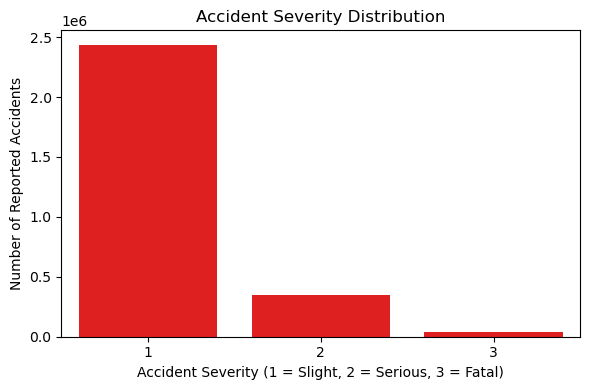

In [ ]:
# Plot: Accident Severity Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Accident_Severity', data=df_merged, color='red')
plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity (1 = Slight, 2 = Serious, 3 = Fatal)")
plt.ylabel("Number of Reported Accidents")
plt.tight_layout()
plt.show()

##### Now let us understand the relationship between the independent variables and the dependent variable.

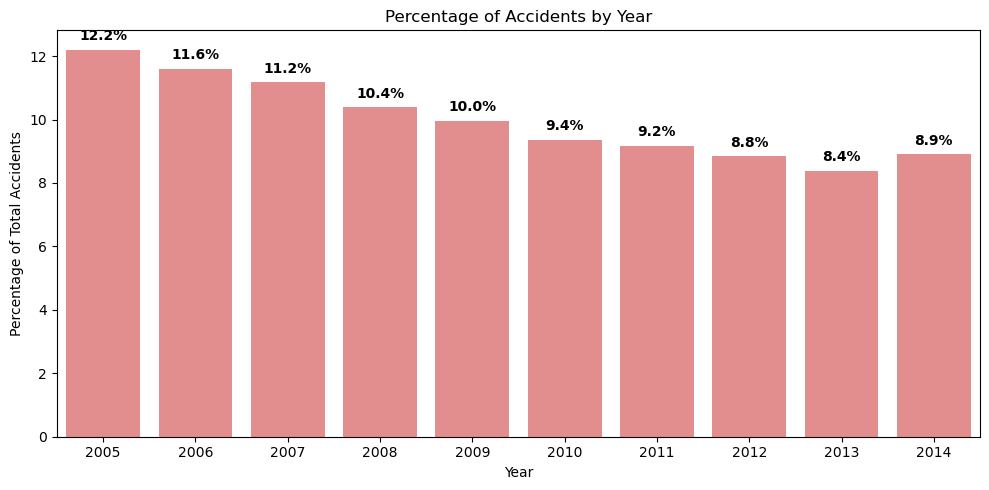

In [ ]:
# Group and calculate percentage
year_percent = df_merged['Year'].value_counts(normalize=True).sort_index() * 100

# Plot Percentage of Accidents by Year
plt.figure(figsize=(10, 5))
sns.barplot(x=year_percent.index, y=year_percent.values, color='lightcoral')

plt.title("Percentage of Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Accidents")

# Annotate each bar
for i, v in enumerate(year_percent.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

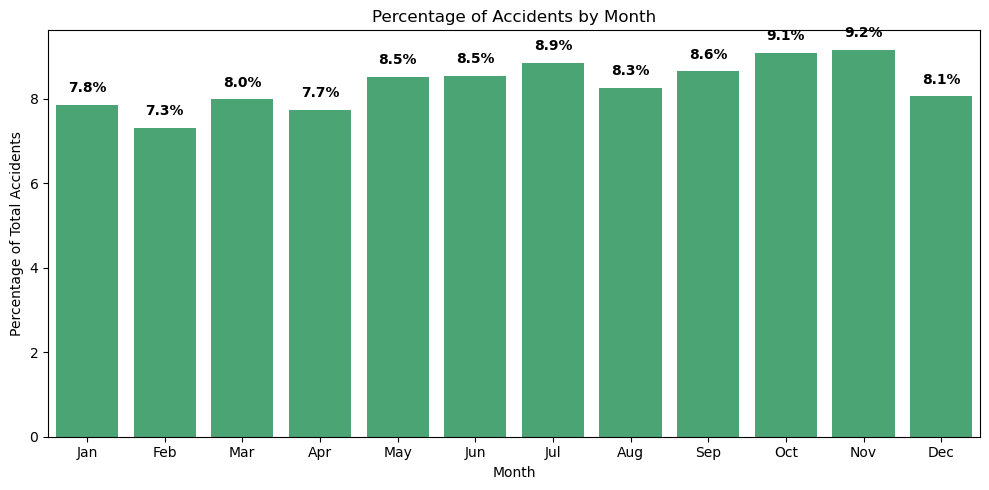

In [ ]:
# Define month order for sorting
month_order = [1,2,3,4,5,6,7,8,9,10,11,12]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate percentage by month
month_percent = df_merged['Month'].value_counts(normalize=True).reindex(month_order) * 100

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=month_labels, y=month_percent.values, color='mediumseagreen')

plt.title("Percentage of Accidents by Month")
plt.xlabel("Month")
plt.ylabel("Percentage of Total Accidents")

# Annotate bars
for i, v in enumerate(month_percent.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

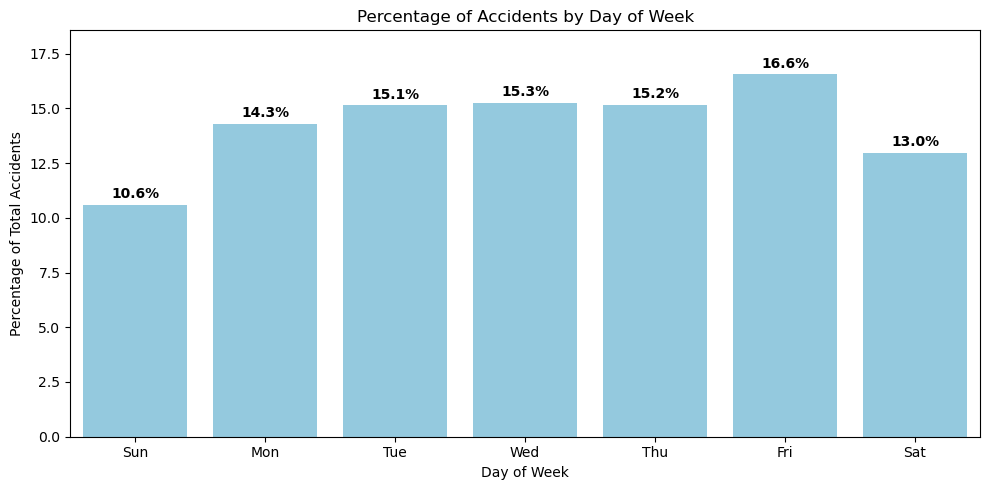

In [ ]:
# get percentage of accidents by day of week
day_percent = df_merged['Day_of_Week'].value_counts(normalize=True) * 100
day_percent = day_percent.reindex(['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'])

# Plot Percentage of Accidents by Day of Week
plt.figure(figsize=(10, 5))
sns.barplot(x=day_percent.index, y=day_percent.values, color='skyblue')

plt.title("Percentage of Accidents by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Percentage of Total Accidents")
plt.ylim(0, day_percent.max() + 2)

# annotate bars with percentage values
for i, v in enumerate(day_percent.values):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

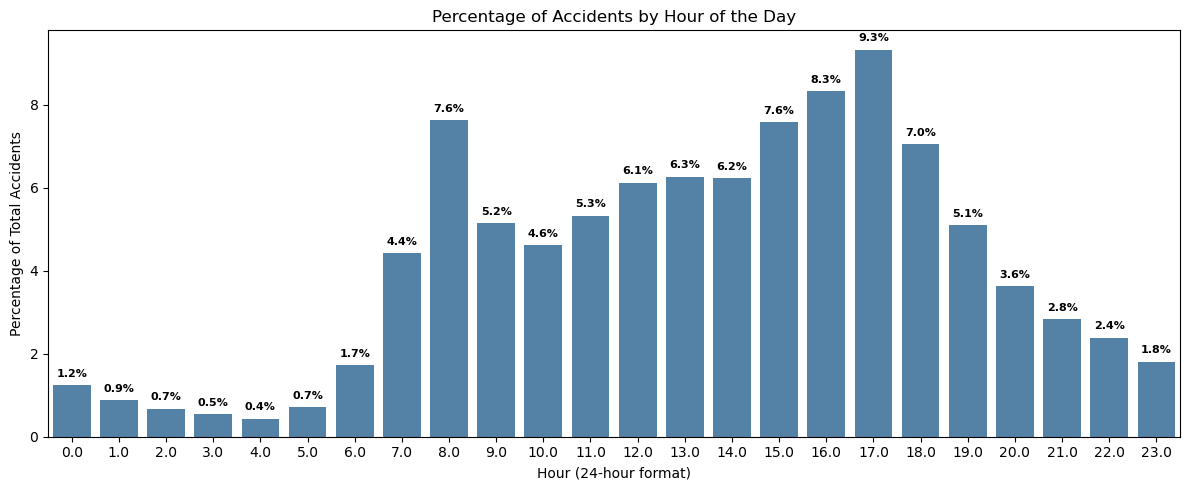

In [ ]:
# Calculate percentage of accidents by hour
hour_percent = df_merged['Hour'].value_counts(normalize=True).sort_index() * 100

# Plot Percentage of Accidents by Hour of the Day
plt.figure(figsize=(12, 5))
sns.barplot(x=hour_percent.index, y=hour_percent.values, color='steelblue')

plt.title("Percentage of Accidents by Hour of the Day")
plt.xlabel("Hour (24-hour format)")
plt.ylabel("Percentage of Total Accidents")

# Annotate each bar with %
for i, v in enumerate(hour_percent.values):
    plt.text(i, v + 0.2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

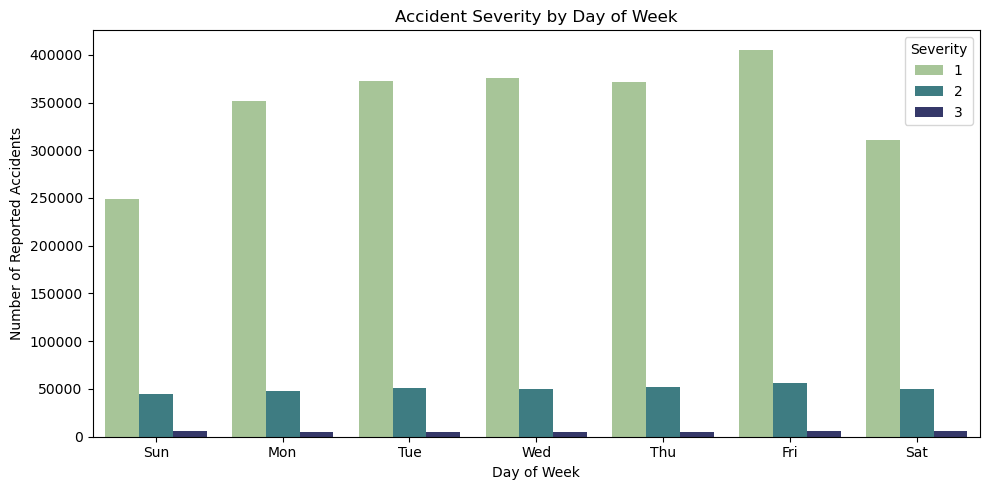

In [ ]:
# Plot Accident Severity by Day of Week
plt.figure(figsize=(10, 5))
sns.countplot(
    x='Day_of_Week',
    hue='Accident_Severity',
    data=df_merged,
    order=['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat'],
    palette='crest'
)
plt.title("Accident Severity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Reported Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

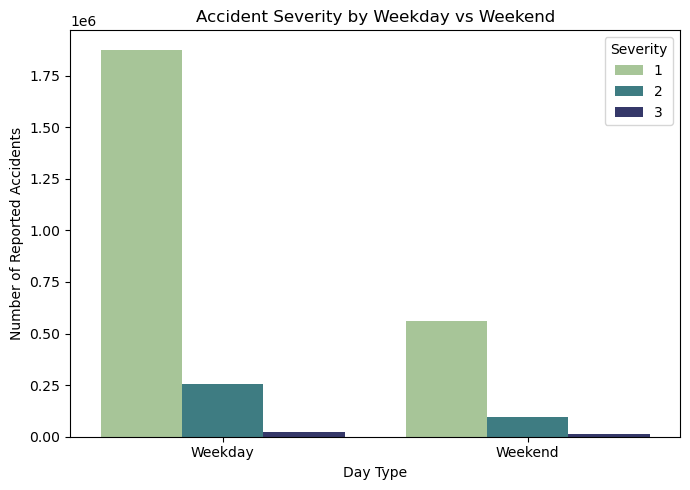

In [ ]:
# Plot Accident Severity by Weekday vs Weekend
plt.figure(figsize=(7, 5))

sns.countplot(
    x='WeekdayEnd',
    hue='Accident_Severity',
    data=df_merged,
    palette='crest'
)

plt.title("Accident Severity by Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Number of Reported Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

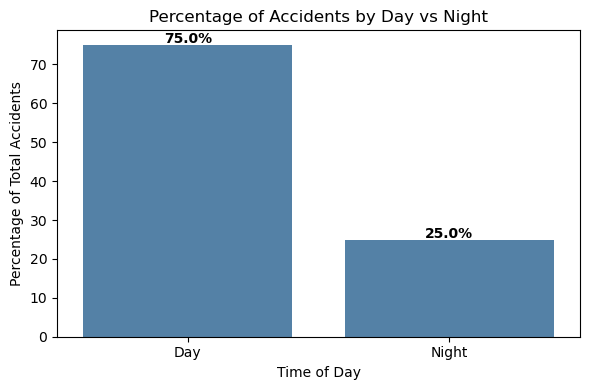

In [ ]:
# Map Light_Conditions to Day/Night
df_merged['Day_Night'] = df_merged['Light_Conditions'].map({
    1: 'Day',
    2: 'Night',
    3: 'Night'
})

# Drop missing
df_merged = df_merged.dropna(subset=['Day_Night'])

# Calculate % of accidents
percent = df_merged['Day_Night'].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=percent.index, y=percent.values, color='steelblue')

plt.title("Percentage of Accidents by Day vs Night")
plt.xlabel("Time of Day")
plt.ylabel("Percentage of Total Accidents")

# Add labels
for i, v in enumerate(percent.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

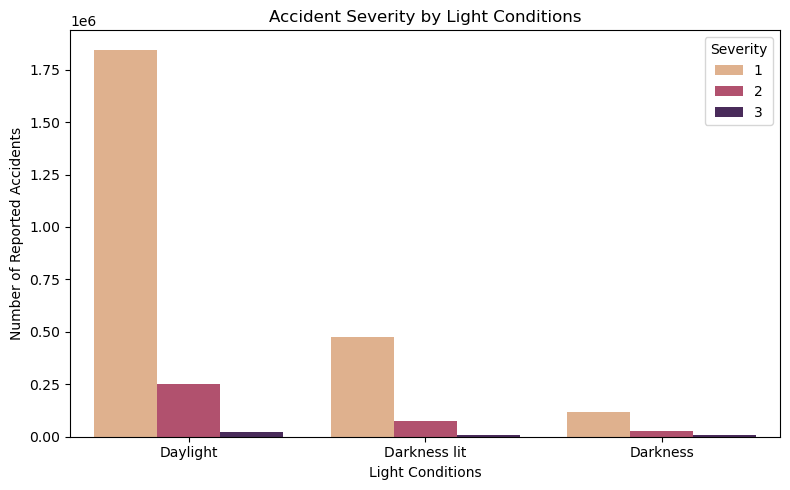

In [ ]:
# Plot: Accident Severity by Light Conditions
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Light_Conditions',
    hue='Accident_Severity',
    data=df_merged,
    palette='flare'
)

# Apply encoded meaning on x-axis labels
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Daylight", "Darkness lit", "Darkness"]
)

plt.title("Accident Severity by Light Conditions")
plt.xlabel("Light Conditions")
plt.ylabel("Number of Reported Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

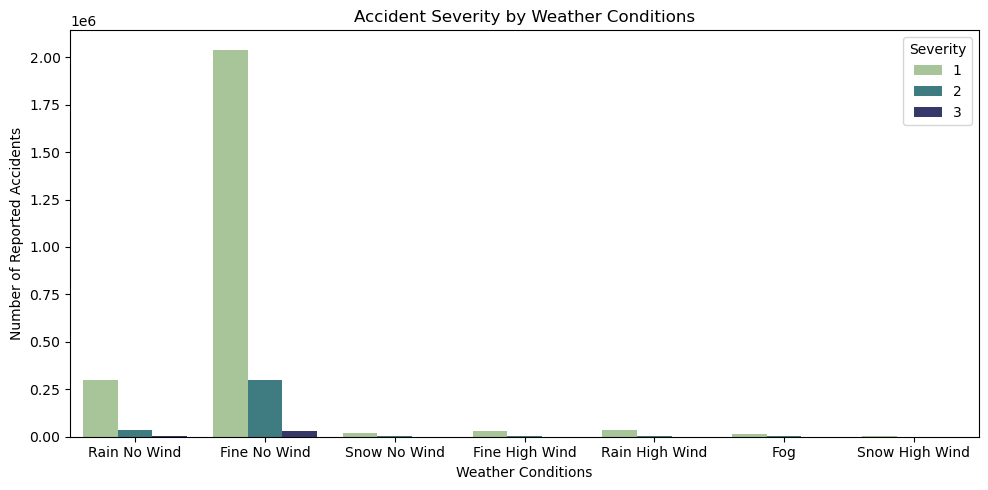

In [ ]:
# Plot: Accident Severity by Weather Conditions
plt.figure(figsize=(10, 5))
sns.countplot(
    x='Weather_Conditions',
    hue='Accident_Severity',
    data=df_merged,
    palette='crest'
)

plt.title("Accident Severity by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Reported Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

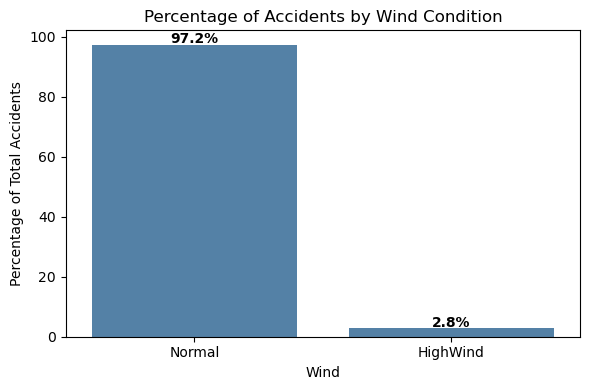

In [ ]:
# Calculate percentages
wind_percent = df_merged['Wind'].value_counts(normalize=True) * 100

# Plot Percentage of Accidents by Wind Condition
plt.figure(figsize=(6, 4))
sns.barplot(x=wind_percent.index, y=wind_percent.values, color='steelblue')

plt.title("Percentage of Accidents by Wind Condition")
plt.xlabel("Wind")
plt.ylabel("Percentage of Total Accidents")

# Add labels
for i, v in enumerate(wind_percent.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

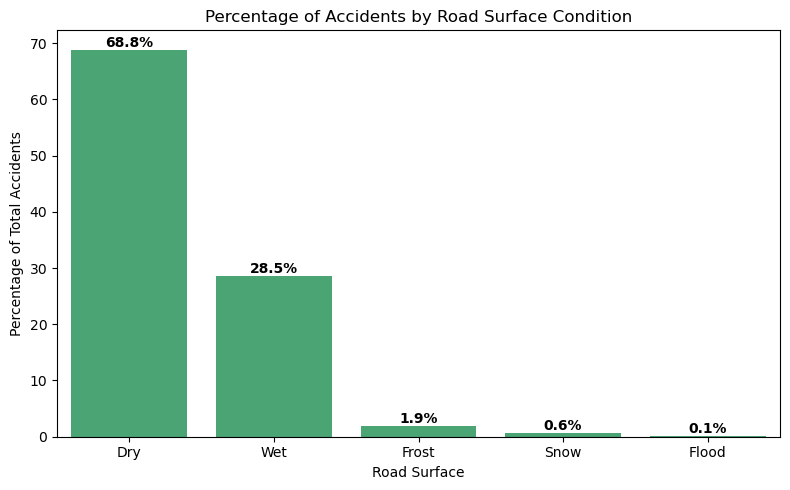

In [ ]:
# Calculate percentage
road_pct = df_merged['RoadSurfaceCategorical'].value_counts(normalize=True) * 100

# Plot Percentage of Accidents by Road Surface Condition
plt.figure(figsize=(8, 5))
sns.barplot(x=road_pct.index, y=road_pct.values, color='mediumseagreen')

plt.title("Percentage of Accidents by Road Surface Condition")
plt.xlabel("Road Surface")
plt.ylabel("Percentage of Total Accidents")

# Add labels
for i, v in enumerate(road_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

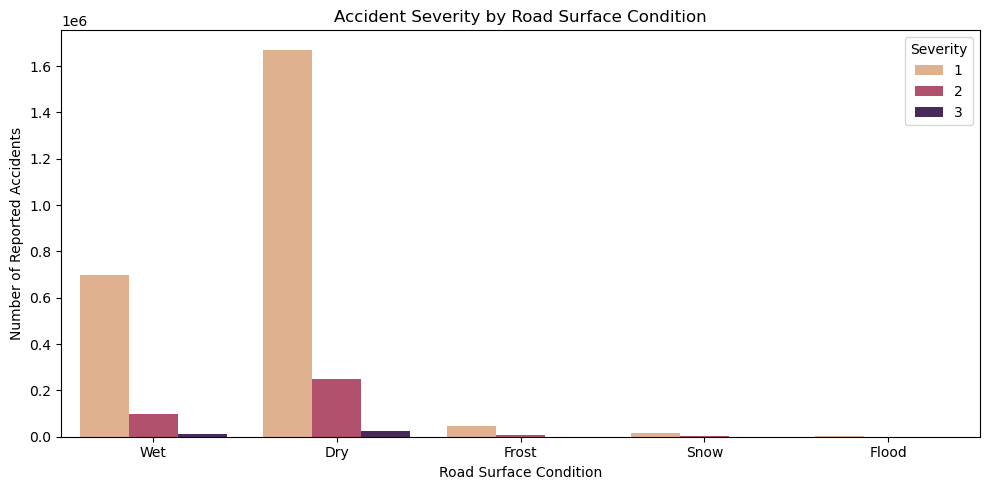

In [ ]:
# Plot Accident Severity by Road Surface Condition
plt.figure(figsize=(10, 5))
sns.countplot(
    x='RoadSurfaceCategorical',
    hue='Accident_Severity',
    data=df_merged,
    palette='flare'
)

plt.title("Accident Severity by Road Surface Condition")
plt.xlabel("Road Surface Condition")
plt.ylabel("Number of Reported Accidents")
plt.legend(title="Severity")
plt.tight_layout()
plt.show()

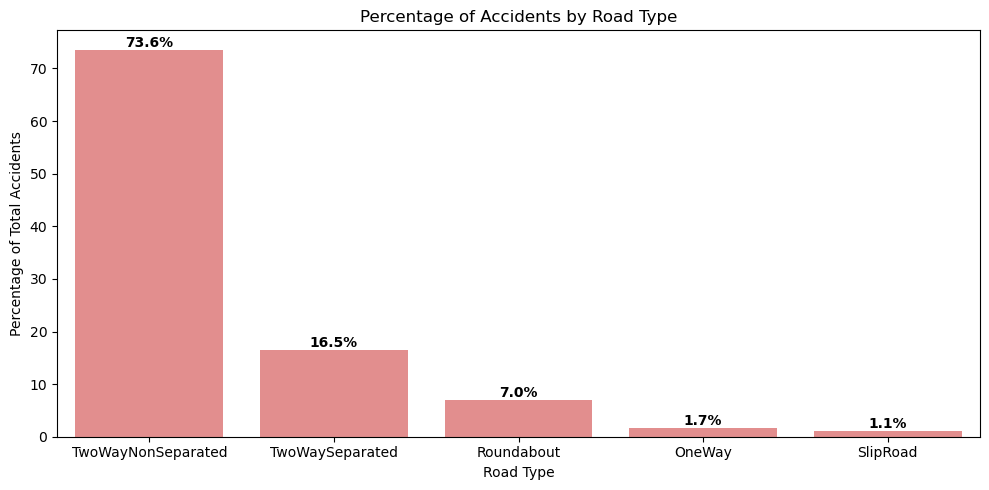

In [ ]:
# Calculate percentage
road_type_pct = df_merged['Road_Type'].value_counts(normalize=True) * 100

# Plot Percentage of Accidents by Road Type
plt.figure(figsize=(10, 5))
sns.barplot(x=road_type_pct.index, y=road_type_pct.values, color='lightcoral')

plt.title("Percentage of Accidents by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Percentage of Total Accidents")

# Add percentage labels
for i, v in enumerate(road_type_pct.values):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

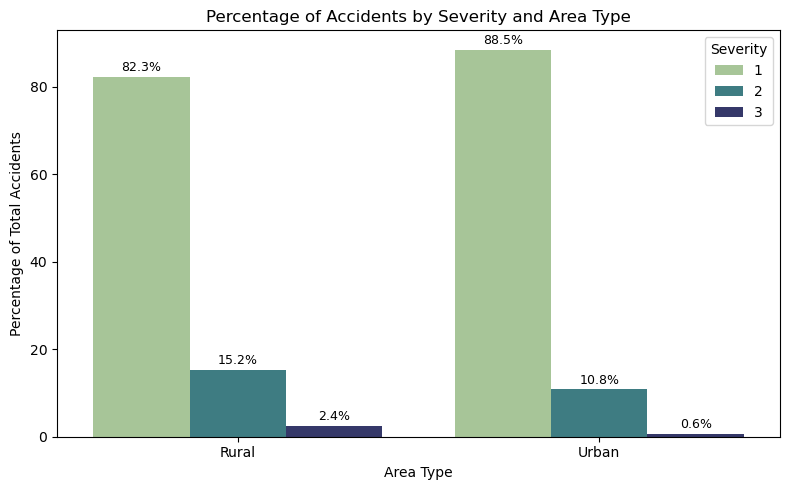

In [ ]:
# Group and calculate %
severity_percent = (
    df_merged.groupby('Urban_or_Rural_Area')['Accident_Severity']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Plot Percentage of Accidents by Severity and Area Type
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Urban_or_Rural_Area',
    y='Percentage',
    hue='Accident_Severity',
    data=severity_percent,
    palette='crest'
)

plt.title("Percentage of Accidents by Severity and Area Type")
plt.xlabel("Area Type")
plt.ylabel("Percentage of Total Accidents")
plt.legend(title="Severity")

# Add % labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=9)

plt.tight_layout()
plt.show()

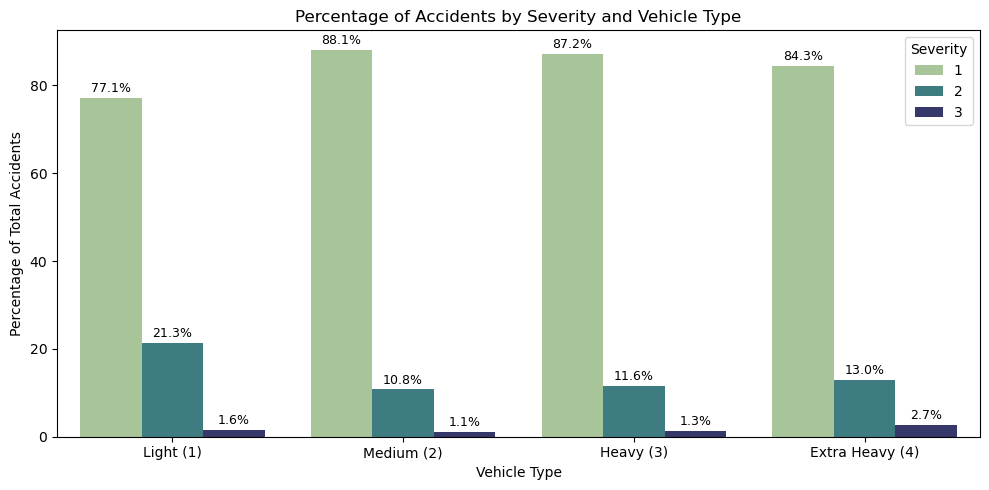

In [ ]:
# Group and calculate percentage
vehicle_severity_pct = (
    df_merged.groupby('Vehicle_Type')['Accident_Severity']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Custom vehicle labels
vehicle_labels = {
    1: 'Light (1)',
    2: 'Medium (2)',
    3: 'Heavy (3)',
    4: 'Extra Heavy (4)'
}

# Map encoded values to labels
vehicle_severity_pct['Vehicle_Type'] = vehicle_severity_pct['Vehicle_Type'].map(vehicle_labels)

# Plot Percentage of Accidents by Severity and Vehicle Type
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x='Vehicle_Type',
    y='Percentage',
    hue='Accident_Severity',
    data=vehicle_severity_pct,
    palette='crest'
)

plt.title("Percentage of Accidents by Severity and Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Percentage of Total Accidents")
plt.legend(title="Severity")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=9)

plt.tight_layout()
plt.show()

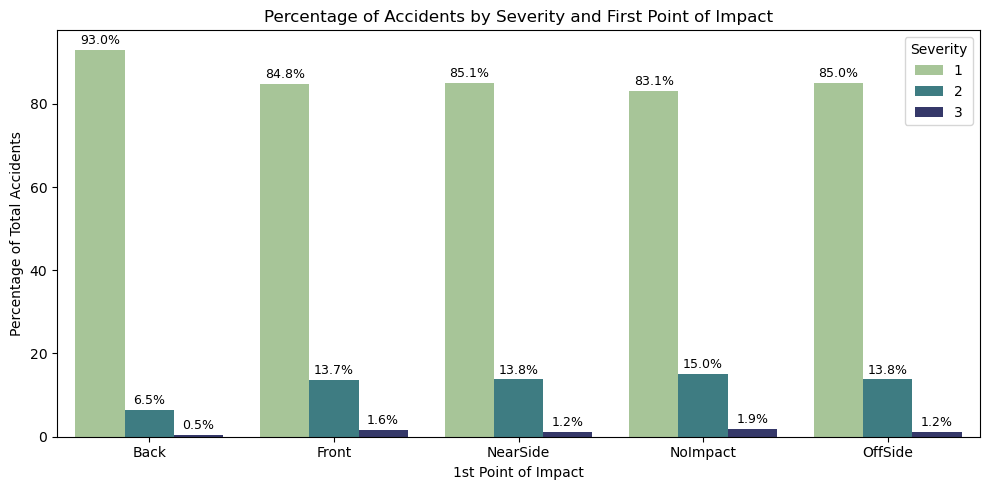

In [ ]:
# Group and calculate percentages
impact_severity_pct = (
    df_merged.groupby('1st_Point_of_Impact')['Accident_Severity']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Plot Percentage of Accidents by Severity and First Point of Impact
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x='1st_Point_of_Impact',
    y='Percentage',
    hue='Accident_Severity',
    data=impact_severity_pct,
    palette='crest'
)

plt.title("Percentage of Accidents by Severity and First Point of Impact")
plt.xlabel("1st Point of Impact")
plt.ylabel("Percentage of Total Accidents")
plt.legend(title="Severity")

# Add % labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=9)

plt.tight_layout()
plt.show()

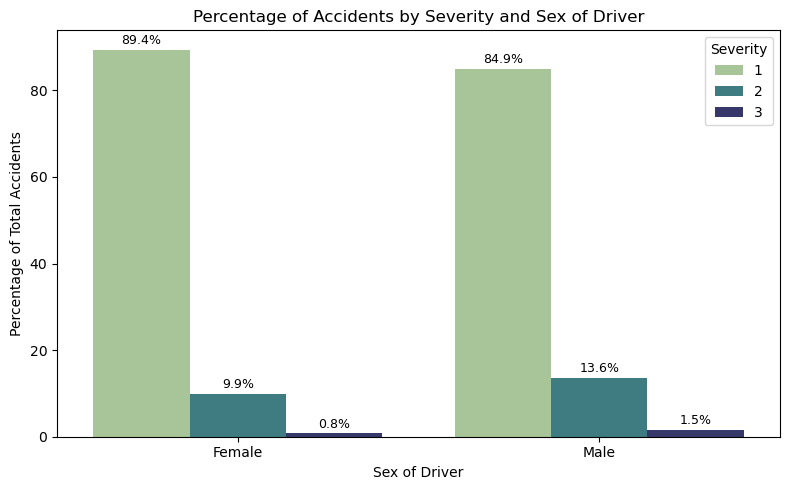

In [ ]:
# Group and calculate percentages
sex_severity_pct = (
    df_merged.groupby('Sex_of_Driver')['Accident_Severity']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

# Plot Percentage of Accidents by Severity and Sex of Driver
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x='Sex_of_Driver',
    y='Percentage',
    hue='Accident_Severity',
    data=sex_severity_pct,
    palette='crest'
)

plt.title("Percentage of Accidents by Severity and Sex of Driver")
plt.xlabel("Sex of Driver")
plt.ylabel("Percentage of Total Accidents")
plt.legend(title="Severity")

# Add % labels above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2, fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# select independent variables
selected_features = ['Number_of_Vehicles','Number_of_Casualties','Light_Conditions','Weather_Conditions','RoadSurfaceCategorical',
                     'Road_Type','Urban_or_Rural_Area','Vehicle_Type','Sex_of_Driver','1st_Point_of_Impact']

X = df_merged[selected_features]
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# select dependent variables
y = df_merged['Accident_Severity']

In [ ]:
# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=500, max_depth=10, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=500, random_state=42)

In [ ]:
# make predictions
y_pred = rf.predict(X_test)

In [ ]:
# evaluate model
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Classification Report:
              precision    recall  f1-score   support

           1       0.86      1.00      0.93    608682
           2       0.66      0.00      0.00     87916
           3       1.00      0.00      0.00      9241

    accuracy                           0.86    705839
   macro avg       0.84      0.33      0.31    705839
weighted avg       0.84      0.86      0.80    705839

Accuracy: 0.8625


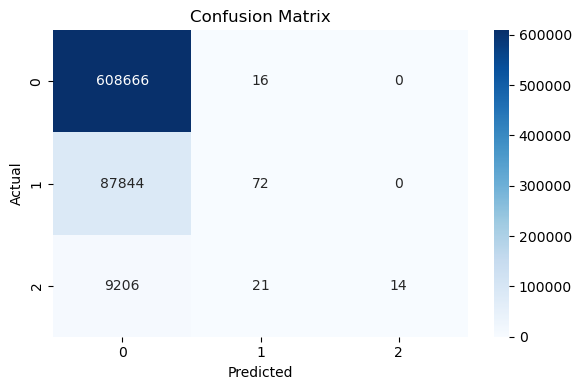

In [ ]:
# plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [ ]:
# get feature importances
importances = rf.feature_importances_
feature_names = X_train.columns

In [ ]:
# create a dataframe for sorting
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

C:\Users\Ashlesha Ingale\AppData\Local\Temp\ipykernel_20720\3364255264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(15), palette='viridis')


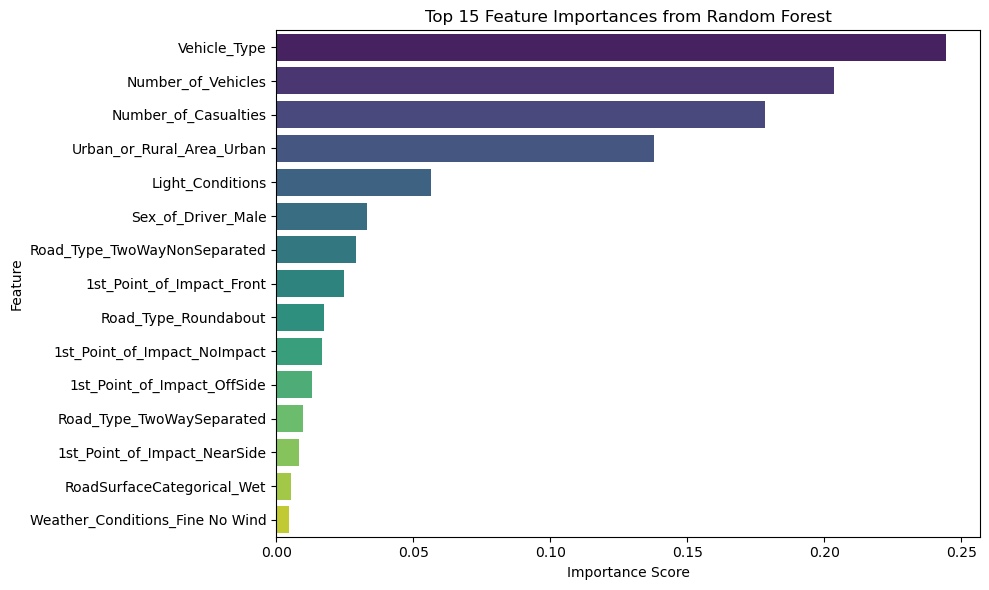

In [ ]:
# plot top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importance_df.head(15), palette='viridis')
plt.title("Top 15 Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()